In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ladda datan
df = pd.read_csv("../data/processed/movies.csv")

# Första översikt
print(df.shape)
print(df.dtypes)
df.head(10)

(100, 6)
movie_id          int64
title               str
release_date        str
rating          float64
popularity      float64
release_year      int64
dtype: object


,movie_id,title,release_date,rating,popularity,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.376,437.4182,2025
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.935,294.0076,2026
2,502356,The Super Mario Bros. Movie,2023-04-05,7.587,203.2750,2023
3,1159831,The Bride!,2026-03-04,6.324,191.4115,2026
4,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.670,130.3975,2025
5,1539104,JUJUTSU KAISEN: Execution,2025-11-07,5.918,60.4784,2025
6,803796,KPop Demon Hunters,2025-06-20,8.028,49.0864,2025
7,991494,The SpongeBob Movie: Search for SquarePants,2025-12-16,6.722,44.4070,2025
8,1246049,Dracula,2025-07-30,7.090,38.8414,2025
9,1117857,In Your Dreams,2025-11-07,6.953,41.6870,2025


In [3]:
df.describe()

,movie_id,rating,popularity,release_year
count,1.000000e+02,100.000000,100.000000,100.000000
mean,4.754727e+05,7.249720,32.179571,2014.040000
std,5.250988e+05,1.063437,56.721089,13.042216
min,2.200000e+01,0.000000,10.805000,1939.000000
25%,2.012750e+03,6.929250,13.045775,2005.750000
50%,2.494040e+05,7.375500,18.373050,2016.500000
75%,9.832312e+05,7.897750,27.405175,2025.000000
max,1.575337e+06,8.534000,437.418200,2026.000000


In [8]:
df.head(20)

,movie_id,title,release_date,rating,popularity,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.376,437.4182,2025
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.935,294.0076,2026
2,502356,The Super Mario Bros. Movie,2023-04-05,7.587,203.2750,2023
3,1159831,The Bride!,2026-03-04,6.324,191.4115,2026
4,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.670,130.3975,2025
5,1539104,JUJUTSU KAISEN: Execution,2025-11-07,5.918,60.4784,2025
6,803796,KPop Demon Hunters,2025-06-20,8.028,49.0864,2025
7,991494,The SpongeBob Movie: Search for SquarePants,2025-12-16,6.722,44.4070,2025
8,1246049,Dracula,2025-07-30,7.090,38.8414,2025
9,1117857,In Your Dreams,2025-11-07,6.953,41.6870,2025


In [ ]:
df.popularity

0     437.4182
1     294.0076
2     203.2750
3     191.4115
4     130.3975
        ...   
95     12.9908
96     12.3914
97     10.8050
98     11.3111
99     11.0468
Name: popularity, Length: 100, dtype: float64

In [31]:
df[['rating', 'popularity', 'release_year']].corr()

,rating,popularity,release_year
rating,1.000000,-0.011332,-0.268450
popularity,-0.011332,1.000000,0.210757
release_year,-0.268450,0.210757,1.000000


In [32]:
print(df.isnull().sum())

movie_id        0
title           0
release_date    0
rating          0
popularity      0
release_year    0
decade          0
dtype: int64


In [19]:
print("Korrelation rating vs popularity:")
print(df[['rating', 'popularity', 'release_year']].corr())

Korrelation rating vs popularity:
                rating  popularity  release_year
rating        1.000000   -0.011332     -0.268450
popularity   -0.011332    1.000000      0.210757
release_year -0.268450    0.210757      1.000000


# Kommande filmer (2025 och framåt)

In [29]:
upcoming = df[df['release_year'] >= 2025].sort_values('popularity', ascending=False)
print(f"Antal kommande/nya filmer: {len(upcoming)}")
print()
print(upcoming[['title', 'release_date', 'rating', 'popularity']].to_string(index=False))

Antal kommande/nya filmer: 30

                                         title release_date  rating  popularity
                          Avatar: Fire and Ash   2025-12-17   7.376    437.4182
                  The Super Mario Galaxy Movie   2026-04-01   6.935    294.0076
                                    The Bride!   2026-03-04   6.324    191.4115
Demon Slayer: Kimetsu no Yaiba Infinity Castle   2025-07-18   7.670    130.3975
                     JUJUTSU KAISEN: Execution   2025-11-07   5.918     60.4784
                            KPop Demon Hunters   2025-06-20   8.028     49.0864
   The SpongeBob Movie: Search for SquarePants   2025-12-16   6.722     44.4070
                                In Your Dreams   2025-11-07   6.953     41.6870
                                       Dracula   2025-07-30   7.090     38.8414
            Chainsaw Man - The Movie: Reze Arc   2025-09-19   8.325     36.5064
                      How to Train Your Dragon   2025-06-06   7.900     35.6220
         

# Bäst betygsatta filmer

In [20]:
top10_rating = df.nlargest(10, 'rating')[['title', 'rating', 'popularity', 'release_year']]
print(top10_rating.to_string(index=False))

                                            title  rating  popularity  release_year
                                    Spirited Away   8.534     32.4806          2001
                                   The Green Mile   8.505     27.1758          1999
    The Lord of the Rings: The Return of the King   8.500     27.6259          2003
                              The Legend of Hei 2   8.500     12.7804          2025
                          Cosmic Princess Kaguya!   8.438     22.0723          2026
The Lord of the Rings: The Fellowship of the Ring   8.430     31.3674          2001
            The Lord of the Rings: The Two Towers   8.414     20.4383          2002
                             Howl's Moving Castle   8.387     18.3129          2004
               Chainsaw Man - The Movie: Reze Arc   8.325     36.5064          2025
                                Princess Mononoke   8.324     14.3465          1997


# Underskattade klassiker (högt betyg, låg popularity)

In [21]:
underrated = df[(df['rating'] >= 7.5) & (df['popularity'] < 20)]
print(underrated[['title', 'rating', 'popularity', 'release_year']].to_string(index=False))

                                                 title  rating  popularity  release_year
                                  Howl's Moving Castle   8.387     18.3129          2004
Pirates of the Caribbean: The Curse of the Black Pearl   7.821     19.2692          2003
                                                  Flow   8.090     18.4650          2024
                                     Princess Mononoke   8.324     14.3465          1997
                Miraculous World: Tokyo, Stellar Force   8.224     17.4267          2025
                                                 Versa   7.932     15.8549          2025
                          Puss in Boots: The Last Wish   8.201     15.1257          2022
Demon Slayer -Kimetsu no Yaiba- The Movie: Mugen Train   8.199     14.2331          2020
                                      Jujutsu Kaisen 0   8.114     14.7477          2021
                                           Ratatouille   7.838     14.5546          2007
                     

# Filmer per decennium

In [22]:
df['decade'] = (df['release_year'] // 10) * 10
print(df.groupby('decade')[['rating', 'popularity']].mean().round(2))

        rating  popularity
decade                    
1930      7.58       12.89
1980      7.79       14.56
1990      7.69       16.37
2000      7.73       21.34
2010      7.05       15.90
2020      7.02       47.94


# Top 10 populäraste

/var/folders/26/rm7wzvs97kvbh7c5dl37h0tm0000gn/T/ipykernel_42470/3152607154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='popularity', y='title', palette='viridis')


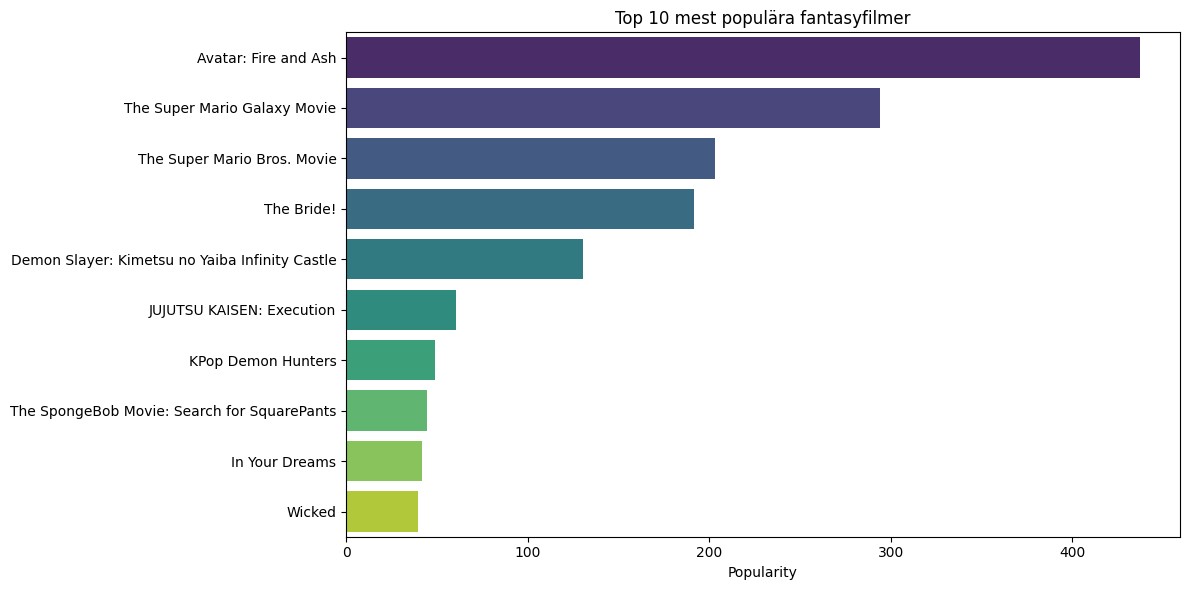

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


top10 = df.nlargest(10, 'popularity')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='popularity', y='title', palette='viridis')
plt.title('Top 10 mest populära fantasyfilmer')
plt.xlabel('Popularity')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Betygsfördelning:

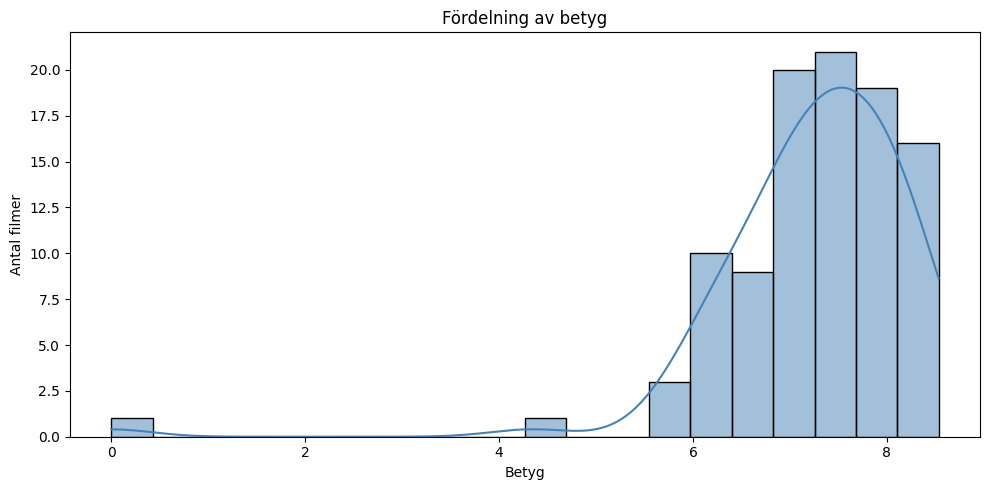

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['rating'], bins=20, kde=True, color='steelblue')
plt.title('Fördelning av betyg')
plt.xlabel('Betyg')
plt.ylabel('Antal filmer')
plt.tight_layout()
plt.show()

# Filmer per år

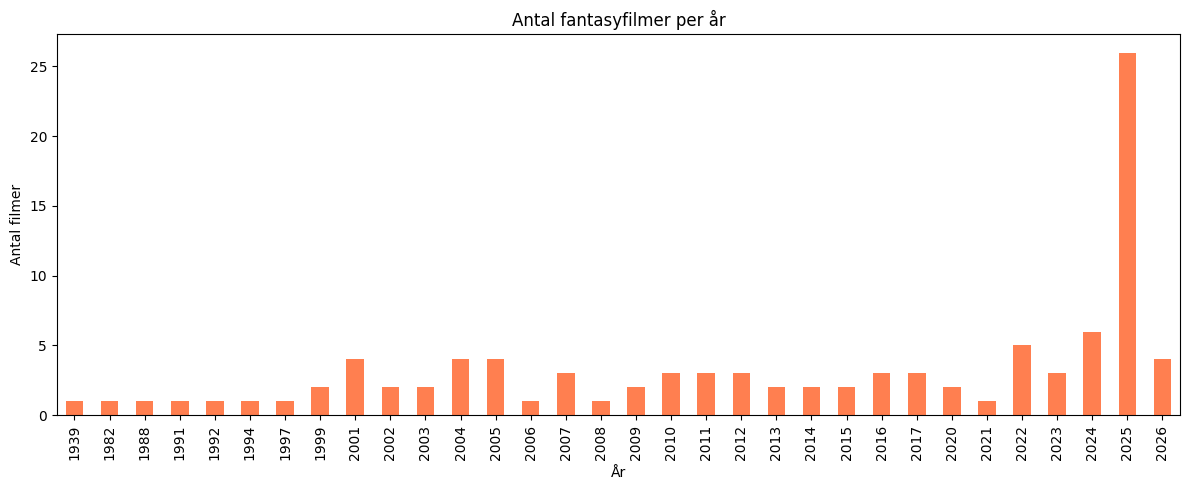

In [6]:
plt.figure(figsize=(12, 5))
df['release_year'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Antal fantasyfilmer per år')
plt.xlabel('År')
plt.ylabel('Antal filmer')
plt.tight_layout()
plt.show()

# Betyg trend över tid:

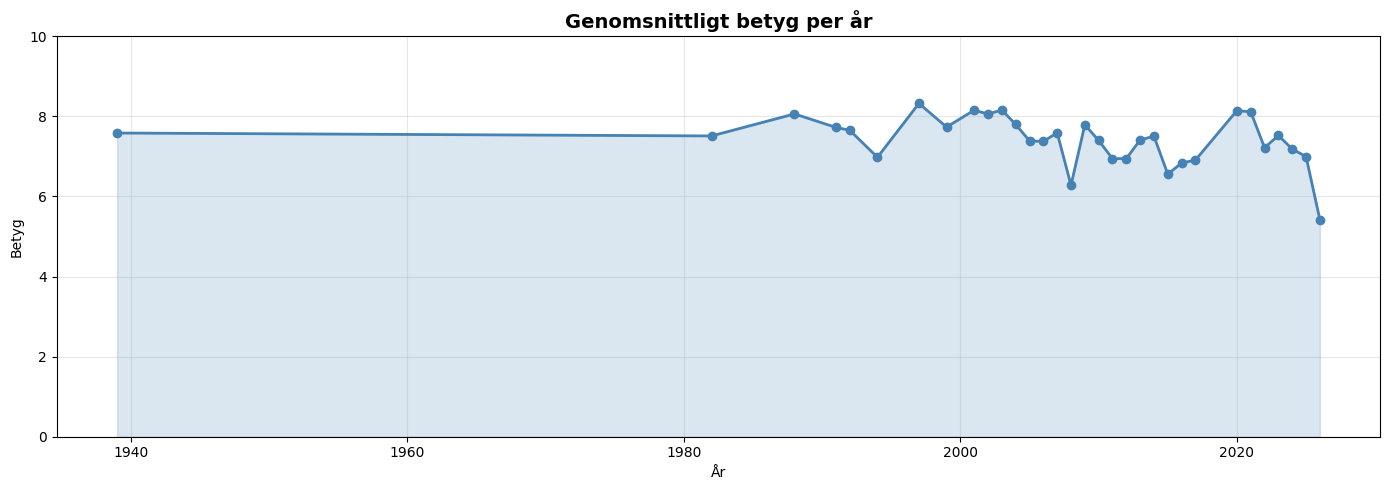

In [24]:
plt.figure(figsize=(14, 5))
year_rating = df.groupby('release_year')['rating'].mean()
plt.plot(year_rating.index, year_rating.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(year_rating.index, year_rating.values, alpha=0.2, color='steelblue')
plt.title('Genomsnittligt betyg per år', fontsize=14, fontweight='bold')
plt.xlabel('År')
plt.ylabel('Betyg')
plt.ylim(0, 10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Popularity trend över tid

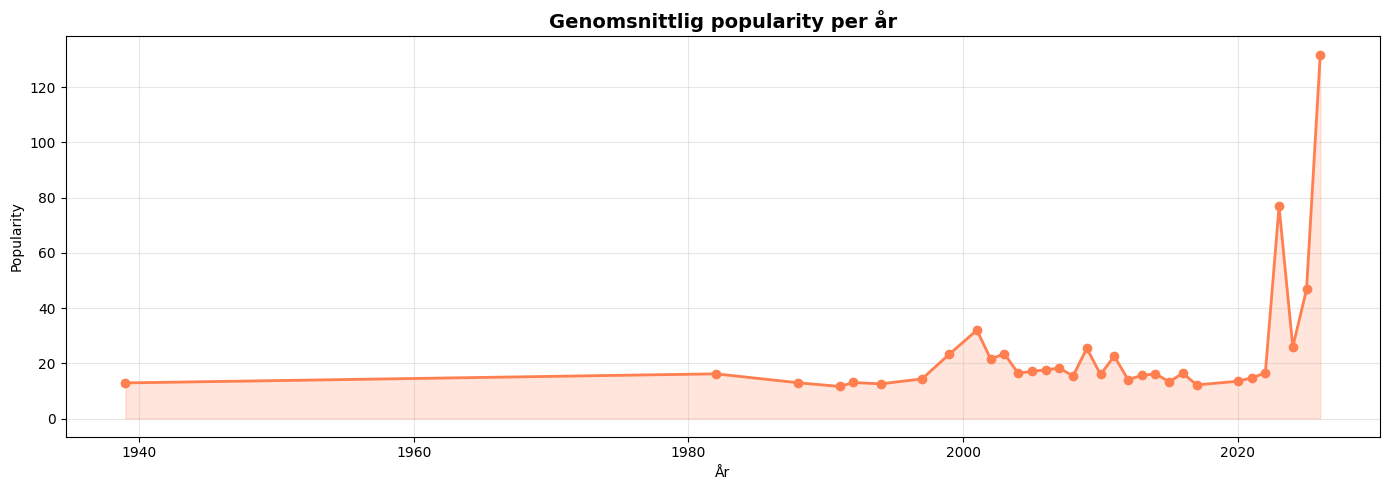

In [25]:
plt.figure(figsize=(14, 5))
year_pop = df.groupby('release_year')['popularity'].mean()
plt.plot(year_pop.index, year_pop.values, marker='o', color='coral', linewidth=2)
plt.fill_between(year_pop.index, year_pop.values, alpha=0.2, color='coral')
plt.title('Genomsnittlig popularity per år', fontsize=14, fontweight='bold')
plt.xlabel('År')
plt.ylabel('Popularity')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Snittbetyg per decennium

/var/folders/26/rm7wzvs97kvbh7c5dl37h0tm0000gn/T/ipykernel_42470/260874734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_avg.index, y=decade_avg.values, palette='coolwarm')


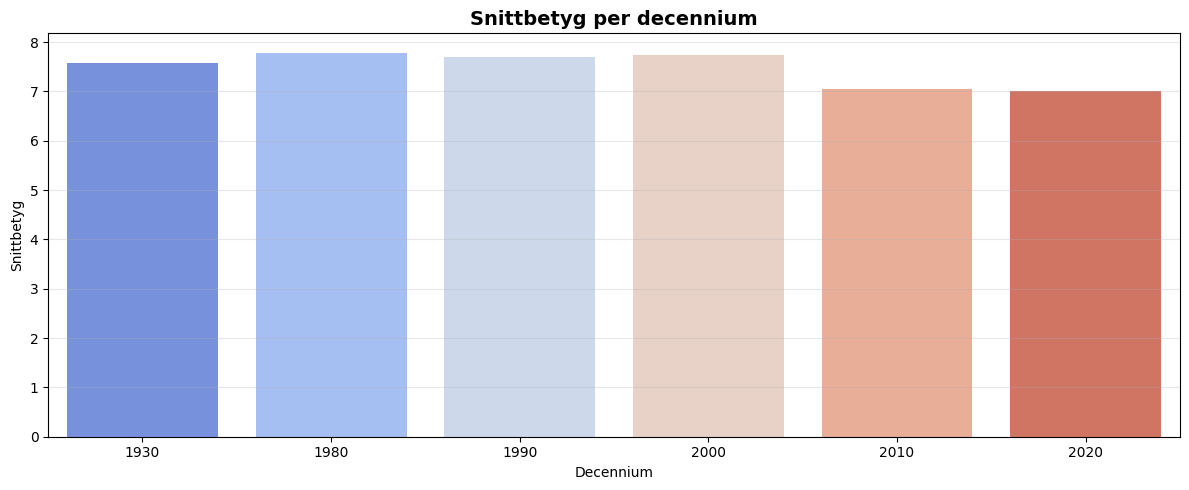

In [26]:
df['decade'] = (df['release_year'] // 10) * 10

plt.figure(figsize=(12, 5))
decade_avg = df.groupby('decade')['rating'].mean()
sns.barplot(x=decade_avg.index, y=decade_avg.values, palette='coolwarm')
plt.title('Snittbetyg per decennium', fontsize=14, fontweight='bold')
plt.xlabel('Decennium')
plt.ylabel('Snittbetyg')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

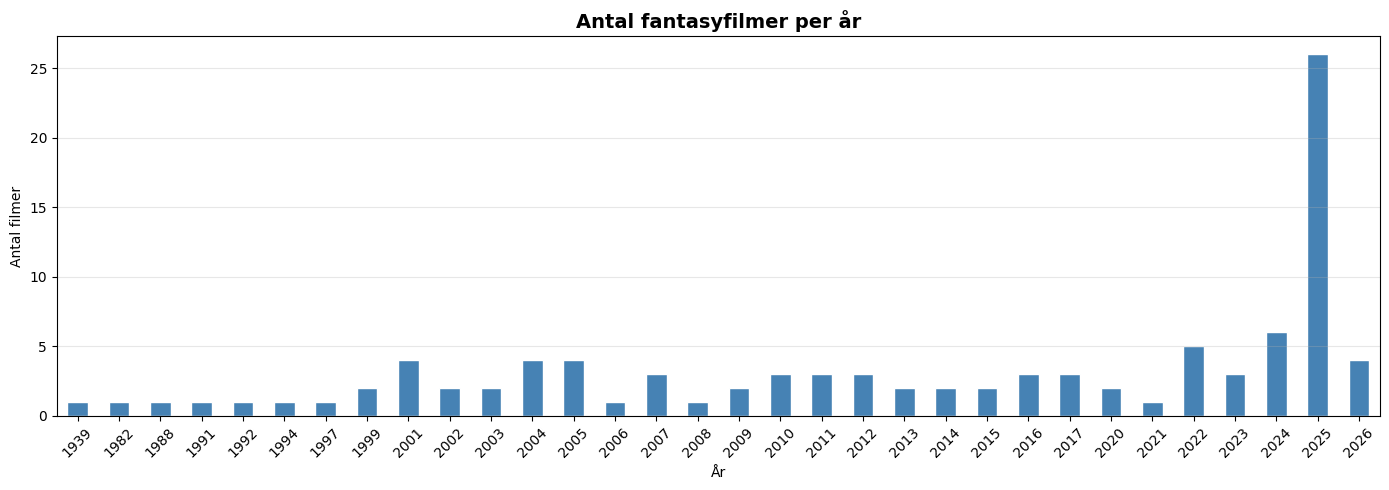

In [27]:
plt.figure(figsize=(14, 5))
df['release_year'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Antal fantasyfilmer per år', fontsize=14, fontweight='bold')
plt.xlabel('År')
plt.ylabel('Antal filmer')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Kommande filmer

/var/folders/26/rm7wzvs97kvbh7c5dl37h0tm0000gn/T/ipykernel_42470/3762567589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=upcoming.head(15), x='popularity', y='title', palette='viridis')


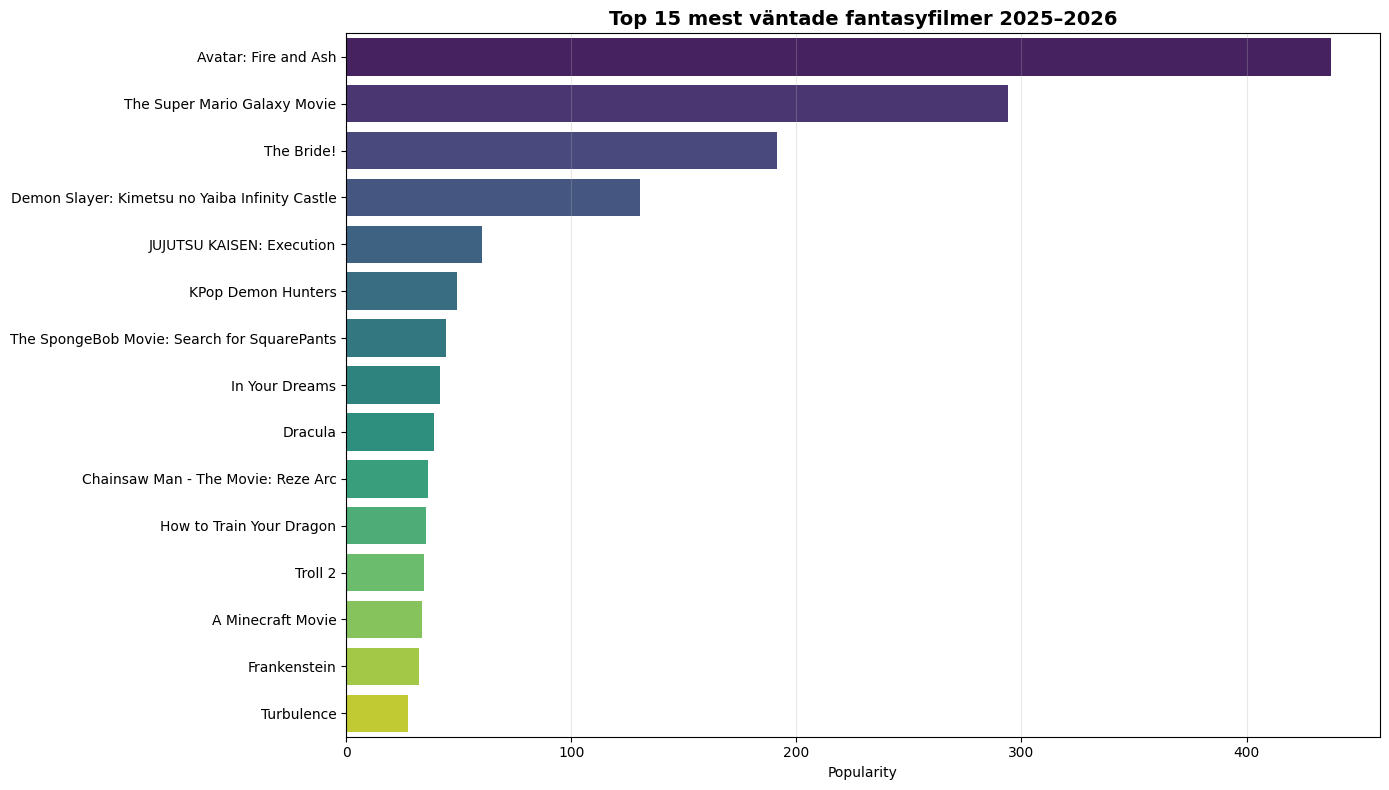

In [30]:
plt.figure(figsize=(14, 8))
sns.barplot(data=upcoming.head(15), x='popularity', y='title', palette='viridis')
plt.title('Top 15 mest väntade fantasyfilmer 2025–2026', fontsize=14, fontweight='bold')
plt.xlabel('Popularity')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()